# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Teguh Wichaksono
- **Email:** CDCC129D6Y0078@student.devacademy.id
- **ID Dicoding:** CDCC129D6Y0078

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Pada musim apa rata-rata jumlah peminjaman sepeda harian paling tinggi dan paling rendah selama periode 2011–2012?
- **Pertanyaan 2:** Bagaimana pola rata-rata jumlah peminjaman sepeda per jam dalam sehari pada hari kerja dibandingkan hari libur selama periode 2011–2012?

## Import Semua Packages/Library yang Digunakan

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

#### Load df_day dan Load df_hour

In [48]:
df_day = pd.read_csv('day.csv')
df_hour = pd.read_csv('hour.csv')

In [49]:
# untuk menampilkan 5 baris utama
df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [50]:
# untuk menampilkan 5 baris utama
df_hour.head()


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**

*   Dataset day.csv berisi 731 baris data peminjaman sepeda harian dari tahun 2011–2012.
*   Dataset hour.csv berisi 17.379 baris data peminjaman sepeda per jam dari tahun 2011–2012.


*   Kedua dataset memiliki kolom yang hampir samaa, hanya dibedakan hour.csv memiliki kolom tambahan hr (jam).










### Assessing Data

#### Mengecek Ringkasan Data

In [51]:
# untuk mengecek secara ringkas tentang data
df_day.info()
df_hour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (tot

**Steps to Take:**
pada tahap ini untuk struktur dan kondisi data secara cepat

#### Mengecek Missing Values

In [52]:
#mengecek missing values pada df_day
df_day.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [53]:
#mengecek missing values pada hour_day
df_hour.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


**Steps to Take:**
pada tahap ini tidak terdeteksi adanya Missing Values, sehingga tidak diperlukan penanganan khusus pada masalah ini.

#### Mengecek Data Duplikat

In [54]:
#mengecek duplikat pada df_day
print('Jumlah duplikat pada df_day:', df_day.duplicated().sum())

Jumlah duplikat pada df_day: 0


In [55]:
# #mengecek duplikat pada df_hour
print('Jumlah duplikat df_hour:', df_hour.duplicated().sum())

Jumlah duplikat df_hour: 0


**Steps to Take:**
pada tahap ini tidak terdeteksi adanya duplikat, sehingga tidak diperlukan penanganan khusus pada masalah ini.

#### Mengecek Tipe Data

In [56]:
# mengecek tipe data pada df_day
df_day.dtypes


,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64
temp,float64


In [57]:
# mengecek tipe data pada df_day
df_hour.dtypes

,0
instant,int64
dteday,object
season,int64
yr,int64
mnth,int64
hr,int64
holiday,int64
weekday,int64
workingday,int64
weathersit,int64


**Steps to Take:**
- Kolom `dteday` masih bertipe`object`, perlu diubah menjadi tipe `datetime` agar bisa digunakan untuk analisis berbasis waktu.

#### Mengecek Statistik Deskriptif & Outlier

In [58]:
# mengecek Statistik deskriptif pada df_day: min, max, mean, std, quartile
df_day.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [59]:
# mengecek Statistik deskriptif pada df_hour: min, max, mean, std, quartile
df_hour.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


In [60]:
# Cek outlier kolom cnt (total peminjaman) di df_day menggunakan metode IQR
Q1 = df_day['cnt'].quantile(0.25)
Q3 = df_day['cnt'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_day = df_day[(df_day['cnt'] < lower_bound) | (df_day['cnt'] > upper_bound)]

print(f'Q1        : {Q1}')
print(f'Q3        : {Q3}')
print(f'IQR       : {IQR}')
print(f'Batas bawah: {lower_bound}')
print(f'Batas atas : {upper_bound}')
print(f'Jumlah outlier df_day: {len(outliers_day)}')

Q1        : 3152.0
Q3        : 5956.0
IQR       : 2804.0
Batas bawah: -1054.0
Batas atas : 10162.0
Jumlah outlier df_day: 0


In [61]:
# Cek outlier kolom cnt di df_hour menggunakan metode IQR
Q1_h = df_hour['cnt'].quantile(0.25)
Q3_h = df_hour['cnt'].quantile(0.75)
IQR_h = Q3_h - Q1_h

lower_bound_h = Q1_h - 1.5 * IQR_h
upper_bound_h = Q3_h + 1.5 * IQR_h

outliers_hour = df_hour[(df_hour['cnt'] < lower_bound_h) | (df_hour['cnt'] > upper_bound_h)]

print(f'Q1        : {Q1_h}')
print(f'Q3        : {Q3_h}')
print(f'IQR       : {IQR_h}')
print(f'Batas bawah: {lower_bound_h}')
print(f'Batas atas : {upper_bound_h}')
print(f'Jumlah outlier df_hour: {len(outliers_hour)}')

Q1        : 40.0
Q3        : 281.0
IQR       : 241.0
Batas bawah: -321.5
Batas atas : 642.5
Jumlah outlier df_hour: 505


**Steps to Take:**
- Dari hasil `describe()`, nilai `min` kolom `cnt` adalah 22 (df_day) dan 1 (df_hour), tidak ada nilai negatif yang tidak masuk akal.
- Ditemukan beberapa outlier pada kolom `cnt` di kedua dataset menggunakan metode IQR. Namun karena data ini merupakan data peminjaman nyata yang dipengaruhi faktor utama yaitu musim dan cuaca, outlier tersebut dianggap **wajar** dan **tidak dihapus**.

**Insight:**
- `df_day` memiliki 731 baris dan 16 kolom.
- `df_hour` memiliki 17.379 baris dan 17 kolom.
- Kolom `dteday` pada kedua dataset masih bertipe `object`, perlu diubah ke `datetime`.
- Tidak ada kolom yang menunjukkan non-null count lebih kecil dari jumlah total baris, artinya tidak ada missing values.

### Cleaning Data

#### Fixing ... problem

#### Mengubah Tipe Data Kolom `dteday` dari object menjadi datetime

In [62]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

print('Tipe data dteday df_day :', df_day['dteday'].dtype)
print('Tipe data dteday df_hour:', df_hour['dteday'].dtype)

Tipe data dteday df_day : datetime64[ns]
Tipe data dteday df_hour: datetime64[ns]


#### Mengubah Nilai Kolom mejadi Kategorikal Suoaya Lebih Mudah Dibaca

In [63]:
# Mapping season: 1=Spring, 2=Summer, 3=Fall, 4=Winter
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
df_day['season_label'] = df_day['season'].map(season_map)
df_hour['season_label'] = df_hour['season'].map(season_map)

print('Kolom baru berhasil ditambahkan!')
df_day[['season', 'season_label']].head(5)

Kolom baru berhasil ditambahkan!


,season,season_label
0,1,Spring
1,1,Spring
2,1,Spring
3,1,Spring
4,1,Spring


In [64]:
# Mapping workingday: 0=Libur, 1=Hari Kerja
workingday_map = {0: 'Libur', 1: 'Hari Kerja'}
df_hour['workingday_label'] = df_hour['workingday'].map(workingday_map)

df_hour[['workingday', 'workingday_label']].head(5)

,workingday,workingday_label
0,0,Libur
1,0,Libur
2,0,Libur
3,0,Libur
4,0,Libur


**Insight:**
- Setelah melakukan tahap cleaning, kedua dataset sudah bersih dan siap digunakan untuk analisis lebih lanjut.
- Kolom `dteday` sudah bertipe datetime dan kolom label kategorikal sudah ditambahkan untuk memudahkan dalam proses visualisasi.

## Exploratory Data Analysis (EDA)

### Explore ...

### Explore Pertanyaan 1: ** Pada musim apa rata-rata jumlah peminjaman sepeda harian paling tinggi dan paling rendah selama periode 2011–2012?

In [65]:
# Rata-rata peminjaman harian per musim
avg_per_season = df_day.groupby('season_label')['cnt'].mean().reset_index()
avg_per_season.columns = ['Musim', 'Rata-rata Peminjaman']
avg_per_season = avg_per_season.sort_values('Rata-rata Peminjaman', ascending=False)
avg_per_season

,Musim,Rata-rata Peminjaman
0,Fall,5644.303191
2,Summer,4992.331522
3,Winter,4728.162921
1,Spring,2604.132597


**Insight:**
Dari data tersebut dapat di simpulkan bahwasannya
- Musim **Fall (Gugur)** memiliki rata-rata peminjaman harian tertinggi.
- Musim **Spring (Semi)** memiliki rata-rata peminjaman harian terendah.

### Explore ...

### Explore Pertanyaan 2: ** Bagaimana pola rata-rata jumlah peminjaman sepeda per jam dalam sehari pada hari kerja dibandingkan hari libur selama periode 2011–2012?

In [66]:
# Rata-rata peminjaman per jam berdasarkan hari kerja vs libur
avg_per_hour = df_hour.groupby(['hr', 'workingday_label'])['cnt'].mean().reset_index()
avg_per_hour.columns = ['Jam', 'Jenis Hari', 'Rata-rata Peminjaman']
avg_per_hour.head(10)

,Jam,Jenis Hari,Rata-rata Peminjaman
0,0,Hari Kerja,36.786290
1,0,Libur,90.800000
2,1,Hari Kerja,16.552632
3,1,Libur,69.508696
4,2,Hari Kerja,8.683778
5,2,Libur,53.171053
6,3,Hari Kerja,4.942553
7,3,Libur,25.775330
8,4,Hari Kerja,5.429787
9,4,Libur,8.264317


**Insight:**
- Pada **hari kerja**, terlihat ada dua puncak peminjaman yang kemungkinan berhubungan dengan jam berangkat dan pulang kerja.
- Pada **hari libur**, peminjaman cenderung merata di siang hari tanpa puncak yang tajam.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada musim apa rata-rata jumlah peminjaman sepeda harian paling tinggi dan paling rendah selama periode 2011–2012?

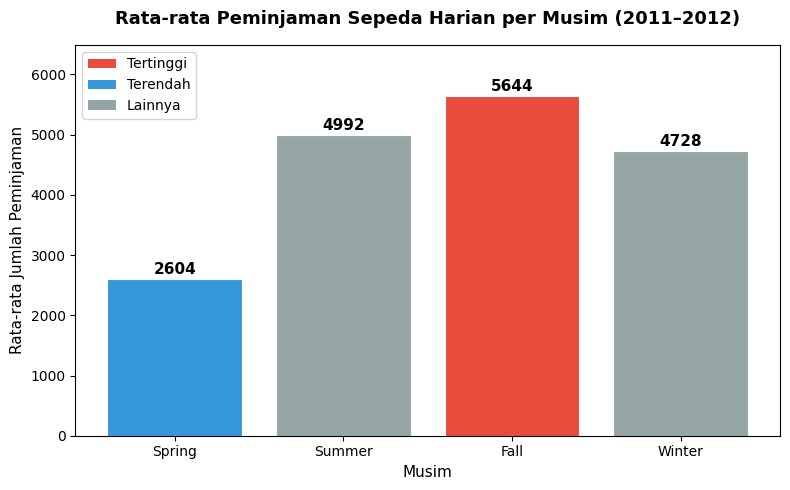

In [67]:
# Urutkan berdasarkan urutan musim yang logis
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
avg_per_season_ordered = avg_per_season.set_index('Musim').reindex(season_order).reset_index()

# Buat warna khusus untuk nilai tertinggi dan terendah
max_val = avg_per_season_ordered['Rata-rata Peminjaman'].max()
min_val = avg_per_season_ordered['Rata-rata Peminjaman'].min()
colors = ['#e74c3c' if v == max_val else '#3498db' if v == min_val else '#95a5a6'
          for v in avg_per_season_ordered['Rata-rata Peminjaman']]

plt.figure(figsize=(8, 5))
bars = plt.bar(avg_per_season_ordered['Musim'],
               avg_per_season_ordered['Rata-rata Peminjaman'],
               color=colors, edgecolor='white', linewidth=0.8)

# Tambahkan label angka di atas tiap bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + 30,
             f'{height:.0f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Rata-rata Peminjaman Sepeda Harian per Musim (2011–2012)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Musim', fontsize=11)
plt.ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
plt.ylim(0, avg_per_season_ordered['Rata-rata Peminjaman'].max() * 1.15)

# Legenda manual
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Tertinggi'),
                   Patch(facecolor='#3498db', label='Terendah'),
                   Patch(facecolor='#95a5a6', label='Lainnya')]
plt.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

**Insight:**
- Musim **Fall (Gugur)** memiliki rata-rata peminjaman sepeda harian **tertinggi** (~5.644 peminjaman/hari), ditandai dengan warna merah.
- Musim **Spring (Semi)** memiliki rata-rata peminjaman **terendah** (~2.604 peminjaman/hari), ditandai dengan warna biru.
- Selisih antara musim paling ramai dan paling sepi cukup besar, lebih dari **2x lipat**. Ini menunjukkan bahwa musim sangat memengaruhi minat orang untuk bersepeda.

### Pertanyaan 2: Bagaimana pola rata-rata jumlah peminjaman sepeda per jam dalam sehari pada hari kerja dibandingkan hari libur selama periode 2011–2012?

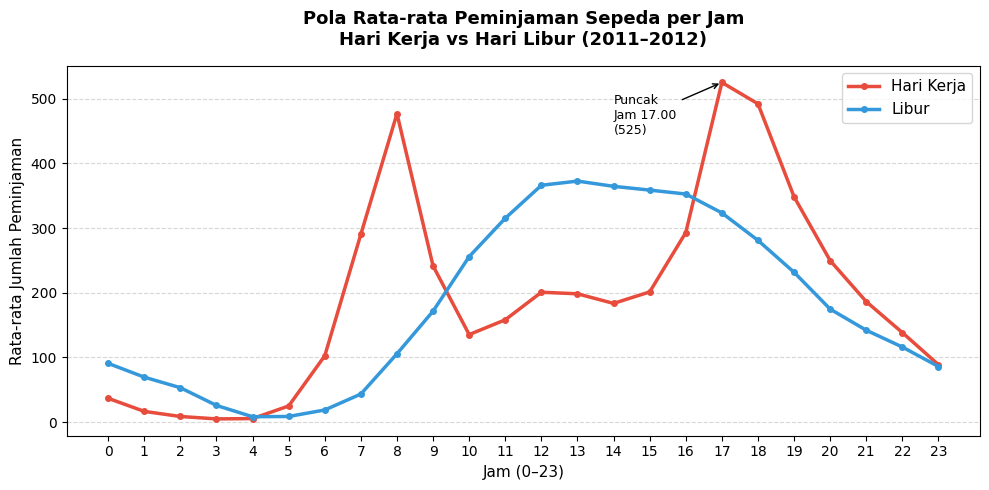

In [68]:
# Pisahkan data hari kerja dan libur
workday_data = avg_per_hour[avg_per_hour['Jenis Hari'] == 'Hari Kerja']
holiday_data = avg_per_hour[avg_per_hour['Jenis Hari'] == 'Libur']

plt.figure(figsize=(10, 5))

plt.plot(workday_data['Jam'], workday_data['Rata-rata Peminjaman'],
         color='#e74c3c', linewidth=2.5, marker='o', markersize=4, label='Hari Kerja')
plt.plot(holiday_data['Jam'], holiday_data['Rata-rata Peminjaman'],
         color='#3498db', linewidth=2.5, marker='o', markersize=4, label='Libur')

# Tandai puncak jam sibuk hari kerja
peak1 = workday_data.loc[workday_data['Rata-rata Peminjaman'].idxmax()]
plt.annotate(f"Puncak\nJam {int(peak1['Jam'])}.00\n({peak1['Rata-rata Peminjaman']:.0f})",
             xy=(peak1['Jam'], peak1['Rata-rata Peminjaman']),
             xytext=(peak1['Jam'] - 3, peak1['Rata-rata Peminjaman'] - 80),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9)

plt.title('Pola Rata-rata Peminjaman Sepeda per Jam\nHari Kerja vs Hari Libur (2011–2012)',
          fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Jam (0–23)', fontsize=11)
plt.ylabel('Rata-rata Jumlah Peminjaman', fontsize=11)
plt.xticks(range(0, 24))
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

**Insight:**
- Pada **hari kerja** (merah), terdapat dua puncak peminjaman yang sangat jelas:
  - Pagi sekitar **jam 8** → kemungkinan besar orang berangkat kerja/sekolah.
  - Sore sekitar **jam 17–18** → kemungkinan besar orang pulang kerja/sekolah.
- Pada **hari libur** (biru), pola peminjaman lebih landai dan merata dari siang hingga sore (sekitar jam 10–16), tanpa ada puncak yang tajam. Orang cenderung bersepeda santai.
- Pada dini hari (jam 0–5), jumlah peminjaman sangat sedikit di kedua jenis hari.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Rata-rata peminjaman sepeda harian paling tinggi terjadi pada musim **Fall (Gugur)** dengan sekitar **5.644 peminjaman/hari**, sedangkan paling rendah terjadi pada musim **Spring (Semi)** dengan sekitar **2.604 peminjaman/hari**. Perbedaan yang sangat signifikan ini menunjukkan bahwa musim adalah salah satu faktor utama yang memengaruhi minat masyarakat untuk meminjam sepeda.

- **Conclusion pertanyaan 2:** Pola peminjaman sepeda per jam sangat berbeda antara hari kerja dan hari libur. Pada hari kerja, terdapat dua puncak tajam di **jam 8 pagi** dan **jam 17–18 sore**, yang mengindikasikan sepeda digunakan sebagai alat transportasi komuter. Sementara pada hari libur, peminjaman lebih merata di siang hari (jam 10–16) tanpa puncak yang ekstrem, yang mengindikasikan penggunaan bersifat rekreasional.

**Rekomendasi Action Item:**
- Tambah jumlah unit sepeda yang tersedia menjelang dan selama musim Fall, serta lakukan perawatan dan perbaikan sepeda secara berkala pada musim Spring ketika demand sedang rendah.
- Pada hari kerja, pastikan ketersediaan sepeda di stasiun/titik peminjaman sudah penuh sebelum jam 8 pagi dan jam 5 sore untuk mengantisipasi lonjakan permintaan di jam sibuk.
- Manfaatkan hari libur untuk program promosi atau event bersepeda santai guna meningkatkan jumlah peminjaman yang cenderung lebih rendah dibanding hari kerja.

In [69]:
# Menyimpan data yang sudah dibersihkan
df_hour.to_csv('main_data.csv', index=False)
